In [62]:
import copy
import numpy as np
import pandas as pd
import pyscf
import pyscf.cc
import pyscf.mcscf
import ffsim
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# ---- SYSTEM CONFIGURATION (change these to switch system) ----
N_ATOMS   = 10      # 6 for H6, 10 for H10
BOND      = 0.9    # Angstrom
N_REPS    = None      # LUCJ repetitions
OPTIMIZE  = False  # optimiser was misbehaving; keep off for reproducibility
N_PERMS   = 30     # number of random orderings to test
BUDGETS   = [10, 20, 40, 80, 160]   # subspace dimensions to sweep

print("Imports OK")

Imports OK


In [63]:
atoms = [["H", (0, 0, i * BOND)] for i in range(N_ATOMS)]

mol = pyscf.gto.Mole()
mol.build(atom=atoms, basis="sto-3g", symmetry=False, verbose=0)

mf = pyscf.scf.RHF(mol).run(verbose=0)
mol_data = ffsim.MolecularData.from_scf(mf)
norb, nelec = mol_data.norb, mol_data.nelec
n_occ  = nelec[0]
n_virt = norb - n_occ

cc  = pyscf.cc.CCSD(mf).run(verbose=0)
cas = pyscf.mcscf.CASCI(mf, ncas=norb, nelecas=nelec).run(verbose=0)
fci_energy = cas.e_tot

# The locality mask (index-based, as in the SQD papers)
alpha_alpha = [(p, p + 1) for p in range(norb - 1)]
alpha_beta  = [(p, p) for p in range(0, norb, 4)]

print(f"System: H{N_ATOMS} chain, bond = {BOND} A")
print(f"norb = {norb},  nelec = {nelec},  n_occ = {n_occ}, n_virt = {n_virt}")
print()
print(f"HF   = {mf.e_tot:.8f}")
print(f"CCSD = {cc.e_tot:.8f}")
print(f"FCI  = {fci_energy:.8f}")
print(f"CCSD recovers {100*(cc.e_tot - mf.e_tot)/(fci_energy - mf.e_tot):.1f}% of correlation energy")
print()
print(f"Mask keeps {len(alpha_alpha)} same-spin pairs out of {norb*(norb-1)//2}")
print(f"Mask keeps {len(alpha_beta)} opposite-spin pairs at p = {[p for p,_ in alpha_beta]}")

System: H10 chain, bond = 0.9 A
norb = 10,  nelec = (5, 5),  n_occ = 5, n_virt = 5

HF   = -5.23857365
CCSD = -5.37666389
FCI  = -5.37828954
CCSD recovers 98.8% of correlation energy

Mask keeps 9 same-spin pairs out of 45
Mask keeps 3 opposite-spin pairs at p = [0, 4, 8]


In [64]:
def block_permutation(rng):
    """Random permutation preserving the occupied/virtual split.
    Keeps the HF occupation pattern valid so CCSD still works."""
    occ  = rng.permutation(n_occ)
    virt = rng.permutation(n_virt) + n_occ
    return np.concatenate([occ, virt]).astype(int)


def permuted_scf(mf_in, perm):
    """Reorder MO coefficients. Hamiltonian, reference state and ansatz
    all follow consistently from this."""
    mf2 = copy.copy(mf_in)
    mf2.mo_coeff  = mf_in.mo_coeff[:, perm]
    mf2.mo_energy = mf_in.mo_energy[perm]
    mf2.mo_occ    = mf_in.mo_occ[perm]
    return mf2


# Sanity check: identity permutation must be a no-op
md_id = ffsim.MolecularData.from_scf(permuted_scf(mf, np.arange(norb)))
ok = abs(md_id.hf_energy - mol_data.hf_energy) < 1e-10
print("Identity permutation is a no-op:", ok)
assert ok, "Permutation machinery is broken - stop here"

Identity permutation is a no-op: True


In [65]:
def gini(p):
    """Concentration of a probability distribution. Range [0, 1].
    Higher = weight concentrated on fewer configurations."""
    p = np.sort(np.asarray(p))          # ascending
    p = p / p.sum()
    n = len(p)
    idx = np.arange(1, n + 1)
    return 1.0 - 2.0 * np.sum(p * (n - idx + 0.5) / n)


def n_dets_for_weight(p, target=0.99):
    """Compactness: how many determinants hold `target` of the weight."""
    cum = np.cumsum(np.sort(p)[::-1])
    return int(np.searchsorted(cum / cum[-1], target) + 1)


def energy_in_subspace(state, ham_op, n_dets):
    """Diagonalise H in the top-n_dets determinants by amplitude.
    This mimics what SQD does classically after sampling."""
    p = np.abs(state) ** 2
    keep = np.argsort(p)[::-1][:n_dets]
    basis = np.zeros((len(state), n_dets), dtype=complex)
    for j, k in enumerate(keep):
        basis[k, j] = 1.0
    H_sub = basis.conj().T @ np.column_stack(
        [ham_op @ basis[:, j] for j in range(n_dets)]
    )
    return np.real(np.linalg.eigvalsh((H_sub + H_sub.conj().T) / 2)[0])


# Quick check on a trivial distribution
test = np.array([1.0, 0.0, 0.0, 0.0])
print(f"Gini of a fully concentrated distribution: {gini(test):.4f}  (should be near 1)")

Gini of a fully concentrated distribution: 0.7500  (should be near 1)


In [66]:
def lucj_for_permutation(perm, n_reps=N_REPS, optimize=OPTIMIZE):
    """Returns (state, hamiltonian) for the masked LUCJ under this ordering."""
    mf_p = permuted_scf(mf, perm)
    md_p = ffsim.MolecularData.from_scf(mf_p)
    cc_p = pyscf.cc.CCSD(mf_p).run(verbose=0)

    op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
        t2=cc_p.t2, t1=cc_p.t1,
        n_reps=n_reps,
        interaction_pairs=(alpha_alpha, alpha_beta),
        optimize=optimize,
    )

    ham_p = ffsim.linear_operator(md_p.hamiltonian, norb=norb, nelec=nelec)
    ref_p = ffsim.hartree_fock_state(norb, nelec)
    state = ffsim.apply_unitary(ref_p, op, norb=norb, nelec=nelec)
    return state, ham_p


# Baseline check
state0, ham0 = lucj_for_permutation(np.arange(norb))
e0 = np.real(np.vdot(state0, ham0 @ state0))
print(f"Identity LUCJ energy: {e0:.8f}")
print(f"HF energy:            {mf.e_tot:.8f}")
print(f"FCI energy:           {fci_energy:.8f}")
print()
if e0 > mf.e_tot:
    print("WARNING: masked LUCJ is worse than HF. The mask is very aggressive")
    print("for this system size. Results are still valid but note the regime.")

Identity LUCJ energy: -5.26380829
HF energy:            -5.23857365
FCI energy:           -5.37828954



In [67]:
orderings = {"identity": np.arange(norb)}
seen = {tuple(np.arange(norb))}
while len(orderings) < N_PERMS + 1:
    p = block_permutation(rng)
    if tuple(p) not in seen:
        seen.add(tuple(p))
        orderings[f"p{len(orderings):02d}"] = p

rows = []
for name, perm in orderings.items():
    state, ham_p = lucj_for_permutation(perm)
    prob = np.abs(state) ** 2
    prob = prob / prob.sum()

    row = {
        "ordering":  name,
        "perm":      "".join(map(str, perm)),
        "E_full":    np.real(np.vdot(state, ham_p @ state)),
        "gini":      gini(prob),
        "n_dets_99": n_dets_for_weight(prob, 0.99),
    }
    for B in BUDGETS:
        row[f"E_sub_{B}"] = energy_in_subspace(state, ham_p, B)
    rows.append(row)

df = pd.DataFrame(rows)
df["err_full"] = (df["E_full"] - fci_energy) * 1000
for B in BUDGETS:
    df[f"err_{B}"] = (df[f"E_sub_{B}"] - fci_energy) * 1000

cols = ["ordering", "err_full", "gini", "n_dets_99"] + [f"err_{B}" for B in BUDGETS]
print(df[cols].round(2).to_string(index=False))

ordering  err_full  gini  n_dets_99  err_10  err_20  err_40  err_80  err_160
identity    114.48   1.0          4  120.38  111.80  105.26  100.47    86.59
     p01    114.39   1.0          2  116.28  113.06  106.18  101.32    86.60
     p02    113.81   1.0          2  120.38  112.12  105.35   97.44    86.45
     p03    113.68   1.0          3  120.38  109.99  105.35   98.94    84.98
     p04    114.00   1.0          2  116.28  111.46  106.86  100.67    87.98
     p05    113.56   1.0          2  118.82  113.06  106.90   99.91    86.54
     p06    113.70   1.0          3  120.38  109.99  105.35   99.20    86.03
     p07    113.92   1.0          3  120.38  111.47  105.37   99.68    86.72
     p08    114.17   1.0          3  120.38  109.99  105.34  100.60    87.18
     p09    113.85   1.0          1  116.28  113.06  106.19  100.79    86.69
     p10    114.02   1.0          2  120.12  111.47  105.35   98.74    86.58
     p11    113.66   1.0          3  120.38  109.99  105.23   99.56    86.56

In [68]:
print("=" * 62)
print("Q1. Does variational energy predict SQD accuracy?")
print("     (weak correlation => energy is the WRONG selector)")
print("=" * 62)
for B in BUDGETS:
    r = np.corrcoef(df["err_full"], df[f"err_{B}"])[0, 1]
    print(f"  budget {B:3d}:  corr = {r:+.3f}")

print()
print("=" * 62)
print("Q2. Do sampling metrics predict it better?")
print("=" * 62)
for B in BUDGETS:
    rg = np.corrcoef(df["gini"],      df[f"err_{B}"])[0, 1]
    rn = np.corrcoef(df["n_dets_99"], df[f"err_{B}"])[0, 1]
    print(f"  budget {B:3d}:  gini {rg:+.3f}    n_dets_99 {rn:+.3f}")

print()
print("=" * 62)
print("Q3. What does choosing by variational energy actually cost?")
print("=" * 62)
best_var = df.loc[df["err_full"].idxmin(), "ordering"]
for B in BUDGETS:
    best_sqd = df.loc[df[f"err_{B}"].idxmin(), "ordering"]
    chosen   = df.loc[df["err_full"].idxmin(), f"err_{B}"]
    best     = df[f"err_{B}"].min()
    print(f"  budget {B:3d}:  variational picks '{best_var}' ({chosen:.1f} mHa), "
          f"best is '{best_sqd}' ({best:.1f} mHa), cost = {chosen - best:.1f} mHa")

print()
print("=" * 62)
print("Spread across orderings")
print("=" * 62)
print(f"  Variational error: {df.err_full.min():.1f} to {df.err_full.max():.1f} mHa")
for B in BUDGETS:
    print(f"  Subspace error (budget {B:3d}): "
          f"{df[f'err_{B}'].min():.1f} to {df[f'err_{B}'].max():.1f} mHa")

Q1. Does variational energy predict SQD accuracy?
     (weak correlation => energy is the WRONG selector)
  budget  10:  corr = -0.092
  budget  20:  corr = +0.307
  budget  40:  corr = +0.091
  budget  80:  corr = +0.342
  budget 160:  corr = +0.337

Q2. Do sampling metrics predict it better?
  budget  10:  gini -0.639    n_dets_99 +0.736
  budget  20:  gini +0.086    n_dets_99 -0.466
  budget  40:  gini +0.722    n_dets_99 -0.648
  budget  80:  gini -0.071    n_dets_99 -0.155
  budget 160:  gini +0.160    n_dets_99 -0.349

Q3. What does choosing by variational energy actually cost?
  budget  10:  variational picks 'p18' (116.3 mHa), best is 'p29' (116.3 mHa), cost = 0.0 mHa
  budget  20:  variational picks 'p18' (111.5 mHa), best is 'p29' (109.0 mHa), cost = 2.4 mHa
  budget  40:  variational picks 'p18' (106.1 mHa), best is 'p16' (105.2 mHa), cost = 0.9 mHa
  budget  80:  variational picks 'p18' (99.9 mHa), best is 'p02' (97.4 mHa), cost = 2.5 mHa
  budget 160:  variational picks 'p

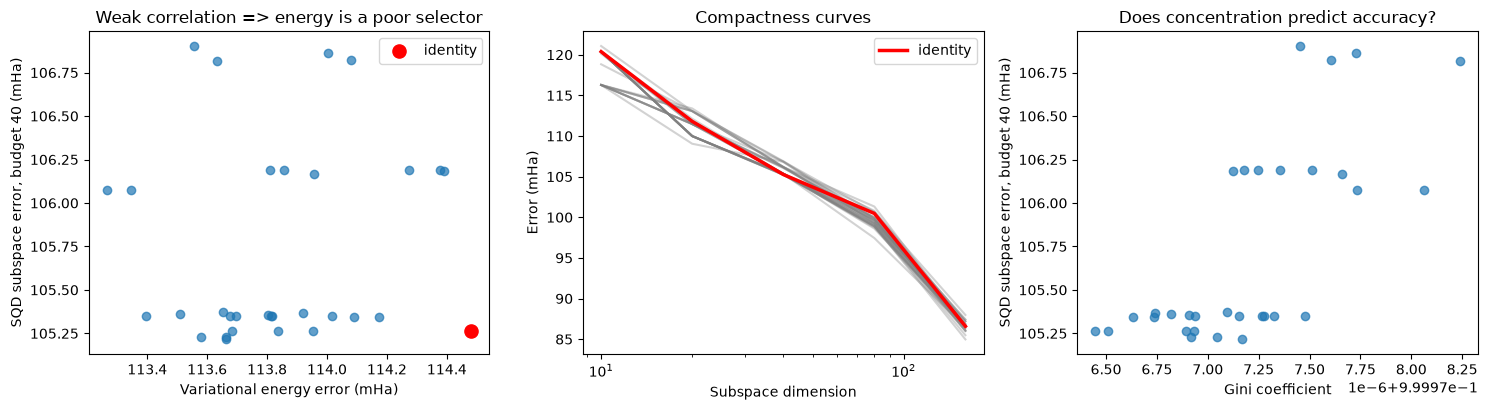

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

B_mid = BUDGETS[len(BUDGETS)//2]

axes[0].scatter(df["err_full"], df[f"err_{B_mid}"], alpha=0.7)
idx = df["ordering"] == "identity"
axes[0].scatter(df.loc[idx, "err_full"], df.loc[idx, f"err_{B_mid}"],
                color="red", s=90, zorder=5, label="identity")
axes[0].set_xlabel("Variational energy error (mHa)")
axes[0].set_ylabel(f"SQD subspace error, budget {B_mid} (mHa)")
axes[0].set_title("Weak correlation => energy is a poor selector")
axes[0].legend()

for _, r in df.iterrows():
    axes[1].plot(BUDGETS, [r[f"err_{B}"] for B in BUDGETS],
                 alpha=0.35, color="grey")
r_id = df[df["ordering"] == "identity"].iloc[0]
axes[1].plot(BUDGETS, [r_id[f"err_{B}"] for B in BUDGETS],
             color="red", lw=2.5, label="identity")
axes[1].set_xscale("log")
axes[1].set_xlabel("Subspace dimension")
axes[1].set_ylabel("Error (mHa)")
axes[1].set_title("Compactness curves")
axes[1].legend()

axes[2].scatter(df["gini"], df[f"err_{B_mid}"], alpha=0.7)
axes[2].set_xlabel("Gini coefficient")
axes[2].set_ylabel(f"SQD subspace error, budget {B_mid} (mHa)")
axes[2].set_title("Does concentration predict accuracy?")

plt.tight_layout()
plt.show()

In [70]:
r_mid = np.corrcoef(df["err_full"], df[f"err_{B_mid}"])[0, 1]

print(f"System: H{N_ATOMS} chain at {BOND} A, {norb} orbitals, {N_PERMS} random orderings")
print(f"LUCJ: n_reps={N_REPS}, optimize={OPTIMIZE}")
print()
print(f"Correlation between variational error and SQD error (budget {B_mid}): {r_mid:+.3f}")
print()
if abs(r_mid) < 0.4:
    print("=> WEAK correlation. Selecting orderings by variational energy")
    print("   does not reliably select good orderings for SQD.")
elif abs(r_mid) > 0.7:
    print("=> STRONG correlation. Variational energy IS a reasonable proxy.")
    print("   The central premise does not hold for this system.")
else:
    print("=> MODERATE correlation. Inconclusive; needs more systems.")

System: H10 chain at 0.9 A, 10 orbitals, 30 random orderings
LUCJ: n_reps=None, optimize=False

Correlation between variational error and SQD error (budget 40): +0.091

=> WEAK correlation. Selecting orderings by variational energy
   does not reliably select good orderings for SQD.


In [71]:
from datetime import datetime

OUTFILE = "sqd_ordering_results.txt"

def save_run(filename=OUTFILE):
    """Append a summary of this run to a text file."""
    B_mid = BUDGETS[len(BUDGETS) // 2]
    lines = []
    W = 70

    lines.append("=" * W)
    lines.append(f"RUN: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    lines.append("=" * W)

    # ---- configuration ----
    lines.append("")
    lines.append("[CONFIGURATION]")
    lines.append(f"  system            : H{N_ATOMS} chain")
    lines.append(f"  bond length (A)   : {BOND}")
    lines.append(f"  basis             : sto-3g")
    lines.append(f"  norb              : {norb}")
    lines.append(f"  nelec             : {nelec}")
    lines.append(f"  n_occ / n_virt    : {n_occ} / {n_virt}")
    lines.append(f"  n_reps            : {N_REPS}")
    lines.append(f"  optimize          : {OPTIMIZE}")
    lines.append(f"  n_permutations    : {N_PERMS}")
    lines.append(f"  budgets           : {BUDGETS}")
    lines.append(f"  mask: same-spin   : {len(alpha_alpha)} pairs of "
                 f"{norb*(norb-1)//2} possible")
    lines.append(f"  mask: opp-spin    : {len(alpha_beta)} pairs at "
                 f"p = {[p for p, _ in alpha_beta]}")

    # ---- reference energies ----
    corr_recovered = 100 * (cc.e_tot - mf.e_tot) / (fci_energy - mf.e_tot)
    lines.append("")
    lines.append("[REFERENCE ENERGIES]  (Hartree)")
    lines.append(f"  HF                : {mf.e_tot:.8f}")
    lines.append(f"  CCSD              : {cc.e_tot:.8f}")
    lines.append(f"  FCI               : {fci_energy:.8f}")
    lines.append(f"  CCSD % of corr.   : {corr_recovered:.1f}%")

    e_id = df.loc[df.ordering == "identity", "E_full"].iloc[0]
    lines.append(f"  identity LUCJ     : {e_id:.8f}")
    lines.append(f"  LUCJ worse than HF: {e_id > mf.e_tot}")

    # ---- key correlations ----
    lines.append("")
    lines.append("[Q1: does variational energy predict SQD accuracy?]")
    for B in BUDGETS:
        r = np.corrcoef(df["err_full"], df[f"err_{B}"])[0, 1]
        lines.append(f"  budget {B:4d}       : corr = {r:+.4f}")

    lines.append("")
    lines.append("[Q2: do sampling metrics predict it better?]")
    for B in BUDGETS:
        rg = np.corrcoef(df["gini"],      df[f"err_{B}"])[0, 1]
        rn = np.corrcoef(df["n_dets_99"], df[f"err_{B}"])[0, 1]
        lines.append(f"  budget {B:4d}       : gini {rg:+.4f}   "
                     f"n_dets_99 {rn:+.4f}")

    lines.append("")
    lines.append("[Q3: cost of selecting by variational energy]")
    best_var = df.loc[df["err_full"].idxmin(), "ordering"]
    for B in BUDGETS:
        best_sqd = df.loc[df[f"err_{B}"].idxmin(), "ordering"]
        chosen   = df.loc[df["err_full"].idxmin(), f"err_{B}"]
        best     = df[f"err_{B}"].min()
        lines.append(f"  budget {B:4d}       : var picks '{best_var}' "
                     f"({chosen:.2f} mHa), best '{best_sqd}' ({best:.2f} mHa), "
                     f"cost {chosen - best:.2f} mHa")

    # ---- spreads ----
    lines.append("")
    lines.append("[SPREAD ACROSS ORDERINGS]  (mHa)")
    lines.append(f"  variational error : {df.err_full.min():8.2f} to "
                 f"{df.err_full.max():8.2f}  (mean {df.err_full.mean():.2f})")
    for B in BUDGETS:
        c = df[f"err_{B}"]
        lines.append(f"  subspace B={B:4d}   : {c.min():8.2f} to {c.max():8.2f}"
                     f"  (mean {c.mean():.2f}, sd {c.std():.2f})")
    lines.append(f"  gini              : {df.gini.min():.4f} to {df.gini.max():.4f}")
    lines.append(f"  n_dets_99         : {df.n_dets_99.min()} to {df.n_dets_99.max()}")

    # ---- verdict ----
    r_mid = np.corrcoef(df["err_full"], df[f"err_{B_mid}"])[0, 1]
    if abs(r_mid) < 0.4:
        verdict = "WEAK correlation -> variational energy is a POOR selector"
    elif abs(r_mid) > 0.7:
        verdict = "STRONG correlation -> variational energy IS a reasonable proxy"
    else:
        verdict = "MODERATE correlation -> inconclusive"
    lines.append("")
    lines.append(f"[VERDICT at budget {B_mid}]  corr = {r_mid:+.4f}")
    lines.append(f"  {verdict}")

    # ---- full table ----
    lines.append("")
    lines.append("[FULL PER-ORDERING DATA]")
    cols = (["ordering", "perm", "err_full", "gini", "n_dets_99"]
            + [f"err_{B}" for B in BUDGETS])
    lines.append(df[cols].round(4).to_string(index=False))
    lines.append("")
    lines.append("")

    text = "\n".join(lines)
    with open(filename, "a") as f:
        f.write(text)

    print(text)
    print(f"\n>>> Appended to {filename}")


save_run()

RUN: 2026-08-19 12:21:59

[CONFIGURATION]
  system            : H10 chain
  bond length (A)   : 0.9
  basis             : sto-3g
  norb              : 10
  nelec             : (5, 5)
  n_occ / n_virt    : 5 / 5
  n_reps            : None
  optimize          : False
  n_permutations    : 30
  budgets           : [10, 20, 40, 80, 160]
  mask: same-spin   : 9 pairs of 45 possible
  mask: opp-spin    : 3 pairs at p = [0, 4, 8]

[REFERENCE ENERGIES]  (Hartree)
  HF                : -5.23857365
  CCSD              : -5.37666389
  FCI               : -5.37828954
  CCSD % of corr.   : 98.8%
  identity LUCJ     : -5.26380859
  LUCJ worse than HF: False

[Q1: does variational energy predict SQD accuracy?]
  budget   10       : corr = -0.0920
  budget   20       : corr = +0.3066
  budget   40       : corr = +0.0914
  budget   80       : corr = +0.3421
  budget  160       : corr = +0.3368

[Q2: do sampling metrics predict it better?]
  budget   10       : gini -0.6390   n_dets_99 +0.7357
  budget 

In [72]:
print(f"HF   = {mf.e_tot:.6f}")
print(f"CCSD = {cc.e_tot:.6f}")
print(f"FCI  = {fci_energy:.6f}\n")

ref = ffsim.hartree_fock_state(norb, nelec)
ham = ffsim.linear_operator(mol_data.hamiltonian, norb=norb, nelec=nelec)

print("UNMASKED (target: should approach CCSD)")
for r in [1, 2, 4, 8, None]:
    op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(t2=cc.t2, t1=cc.t1, n_reps=r)
    s = ffsim.apply_unitary(ref, op, norb=norb, nelec=nelec)
    e = np.real(np.vdot(s, ham @ s))
    p = np.abs(s)**2; p /= p.sum()
    print(f"  n_reps={str(r):>4}: E={e:.6f}  err_vs_CCSD={(e-cc.e_tot)*1000:+8.2f} mHa"
          f"  n_dets_99={n_dets_for_weight(p, 0.99)}")

print("\nMASKED")
for r in [1, 2, 4, 8, None]:
    op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
        t2=cc.t2, t1=cc.t1, n_reps=r,
        interaction_pairs=(alpha_alpha, alpha_beta))
    s = ffsim.apply_unitary(ref, op, norb=norb, nelec=nelec)
    e = np.real(np.vdot(s, ham @ s))
    p = np.abs(s)**2; p /= p.sum()
    print(f"  n_reps={str(r):>4}: E={e:.6f}  err_vs_CCSD={(e-cc.e_tot)*1000:+8.2f} mHa"
          f"  n_dets_99={n_dets_for_weight(p, 0.99)}")

HF   = -5.238574
CCSD = -5.376664
FCI  = -5.378290

UNMASKED (target: should approach CCSD)
  n_reps=   1: E=-5.238815  err_vs_CCSD= +137.85 mHa  n_dets_99=2
  n_reps=   2: E=-5.216234  err_vs_CCSD= +160.43 mHa  n_dets_99=9
  n_reps=   4: E=-5.242271  err_vs_CCSD= +134.39 mHa  n_dets_99=28
  n_reps=   8: E=-5.318351  err_vs_CCSD=  +58.31 mHa  n_dets_99=82
  n_reps=None: E=-5.375446  err_vs_CCSD=   +1.22 mHa  n_dets_99=145

MASKED
  n_reps=   1: E=-5.237949  err_vs_CCSD= +138.71 mHa  n_dets_99=1
  n_reps=   2: E=-5.236146  err_vs_CCSD= +140.52 mHa  n_dets_99=1
  n_reps=   4: E=-5.244042  err_vs_CCSD= +132.62 mHa  n_dets_99=1
  n_reps=   8: E=-5.253941  err_vs_CCSD= +122.72 mHa  n_dets_99=2
  n_reps=None: E=-5.263800  err_vs_CCSD= +112.86 mHa  n_dets_99=4


In [73]:
# How much J-matrix weight does each ordering retain?
def retained_weight(perm):
    mf_p = permuted_scf(mf, perm)
    cc_p = pyscf.cc.CCSD(mf_p).run(verbose=0)
    op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(t2=cc_p.t2, t1=cc_p.t1, n_reps=None)
    J = np.asarray(op.diag_coulomb_mats)      # (n_reps, 2, norb, norb)

    mask_aa = np.zeros((norb, norb), bool)
    for p, q in alpha_alpha:
        mask_aa[p, q] = mask_aa[q, p] = True
    np.fill_diagonal(mask_aa, True)

    mask_ab = np.zeros((norb, norb), bool)
    for p, q in alpha_beta:
        mask_ab[p, q] = mask_ab[q, p] = True

    total = np.sum(J[:, 0]**2) + np.sum(J[:, 1]**2)
    kept  = np.sum((J[:, 0] * mask_aa)**2) + np.sum((J[:, 1] * mask_ab)**2)
    return kept / total

for name, perm in list(orderings.items())[:8]:
    print(f"{name:10s} retains {100*retained_weight(perm):5.1f}% of J weight")

identity   retains  27.1% of J weight
p01        retains  27.1% of J weight
p02        retains  27.1% of J weight
p03        retains  27.1% of J weight
p04        retains  27.1% of J weight
p05        retains  27.1% of J weight
p06        retains  27.1% of J weight
p07        retains  27.1% of J weight


In [74]:
def permute_operator(op, perm):
    """Permute J indices, absorbing the permutation into the orbital rotations.
    The unmasked operator is physically UNCHANGED by this."""
    P = np.eye(op.norb)[list(perm)]

    J = np.asarray(op.diag_coulomb_mats)          # (n_reps, 2, norb, norb)
    U = np.asarray(op.orbital_rotations)          # (n_reps, norb, norb)

    J_new = np.einsum('ij,rsjk,lk->rsil', P, J, P)     # P J P^T
    U_new = np.einsum('rij,kj->rik', U, P)             # U P^T

    kwargs = dict(diag_coulomb_mats=J_new, orbital_rotations=U_new)
    if op.final_orbital_rotation is not None:
        kwargs['final_orbital_rotation'] = op.final_orbital_rotation
    return ffsim.UCJOpSpinBalanced(**kwargs)


def apply_mask(op):
    """Zero out J elements outside the locality constraint."""
    J = np.asarray(op.diag_coulomb_mats).copy()

    m_aa = np.zeros((op.norb, op.norb), bool)
    for p, q in alpha_alpha:
        m_aa[p, q] = m_aa[q, p] = True
    np.fill_diagonal(m_aa, True)

    m_ab = np.zeros((op.norb, op.norb), bool)
    for p, q in alpha_beta:
        m_ab[p, q] = m_ab[q, p] = True

    J[:, 0] *= m_aa
    J[:, 1] *= m_ab

    kwargs = dict(diag_coulomb_mats=J,
                  orbital_rotations=np.asarray(op.orbital_rotations))
    if op.final_orbital_rotation is not None:
        kwargs['final_orbital_rotation'] = op.final_orbital_rotation
    return ffsim.UCJOpSpinBalanced(**kwargs)

In [75]:
ref = ffsim.hartree_fock_state(norb, nelec)
ham = ffsim.linear_operator(mol_data.hamiltonian, norb=norb, nelec=nelec)

def energy(op):
    s = ffsim.apply_unitary(ref, op, norb=norb, nelec=nelec)
    return np.real(np.vdot(s, ham @ s))

op_full = ffsim.UCJOpSpinBalanced.from_t_amplitudes(t2=cc.t2, t1=cc.t1, n_reps=None)
e_ref = energy(op_full)

print(f"Unmasked, identity : {e_ref:.10f}")
for i in range(5):
    perm = rng.permutation(norb)
    e_p = energy(permute_operator(op_full, perm))
    print(f"Unmasked, perm {i}   : {e_p:.10f}   diff = {abs(e_p - e_ref):.2e}")

Unmasked, identity : -5.3754456924
Unmasked, perm 0   : -5.3754456924   diff = 5.77e-14
Unmasked, perm 1   : -5.3754456924   diff = 7.99e-15
Unmasked, perm 2   : -5.3754456924   diff = 6.57e-14
Unmasked, perm 3   : -5.3754456924   diff = 3.15e-13
Unmasked, perm 4   : -5.3754456924   diff = 1.42e-13


In [76]:
def retained_weight(op):
    J = np.asarray(op.diag_coulomb_mats)
    m_aa = np.zeros((op.norb, op.norb), bool)
    for p, q in alpha_alpha:
        m_aa[p, q] = m_aa[q, p] = True
    np.fill_diagonal(m_aa, True)
    m_ab = np.zeros((op.norb, op.norb), bool)
    for p, q in alpha_beta:
        m_ab[p, q] = m_ab[q, p] = True
    total = np.sum(J[:, 0]**2) + np.sum(J[:, 1]**2)
    kept = np.sum((J[:, 0]*m_aa)**2) + np.sum((J[:, 1]*m_ab)**2)
    return kept / total

print(f"\nidentity : {100*retained_weight(op_full):5.1f}%  "
      f"E_masked = {energy(apply_mask(op_full)):.6f}")
for i in range(10):
    perm = rng.permutation(norb)
    op_p = permute_operator(op_full, perm)
    print(f"perm {i:2d}  : {100*retained_weight(op_p):5.1f}%  "
          f"E_masked = {energy(apply_mask(op_p)):.6f}")


identity :  27.1%  E_masked = -5.263800
perm  0  :  15.4%  E_masked = -5.240200
perm  1  :  27.9%  E_masked = -5.244235
perm  2  :  32.5%  E_masked = -5.258626
perm  3  :  20.3%  E_masked = -5.255221
perm  4  :  22.0%  E_masked = -5.254327
perm  5  :  21.5%  E_masked = -5.244243
perm  6  :  26.0%  E_masked = -5.241750
perm  7  :  29.1%  E_masked = -5.246755
perm  8  :  25.7%  E_masked = -5.263967
perm  9  :  24.5%  E_masked = -5.255689
